In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ModuleNotFoundError: No module named 'pandas'

In [ ]:
pip install tensorflow==2.15.0

: 

In [31]:
import os 
import numpy as np
import pandas as pd
import glob
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.models import Sequential

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

: 

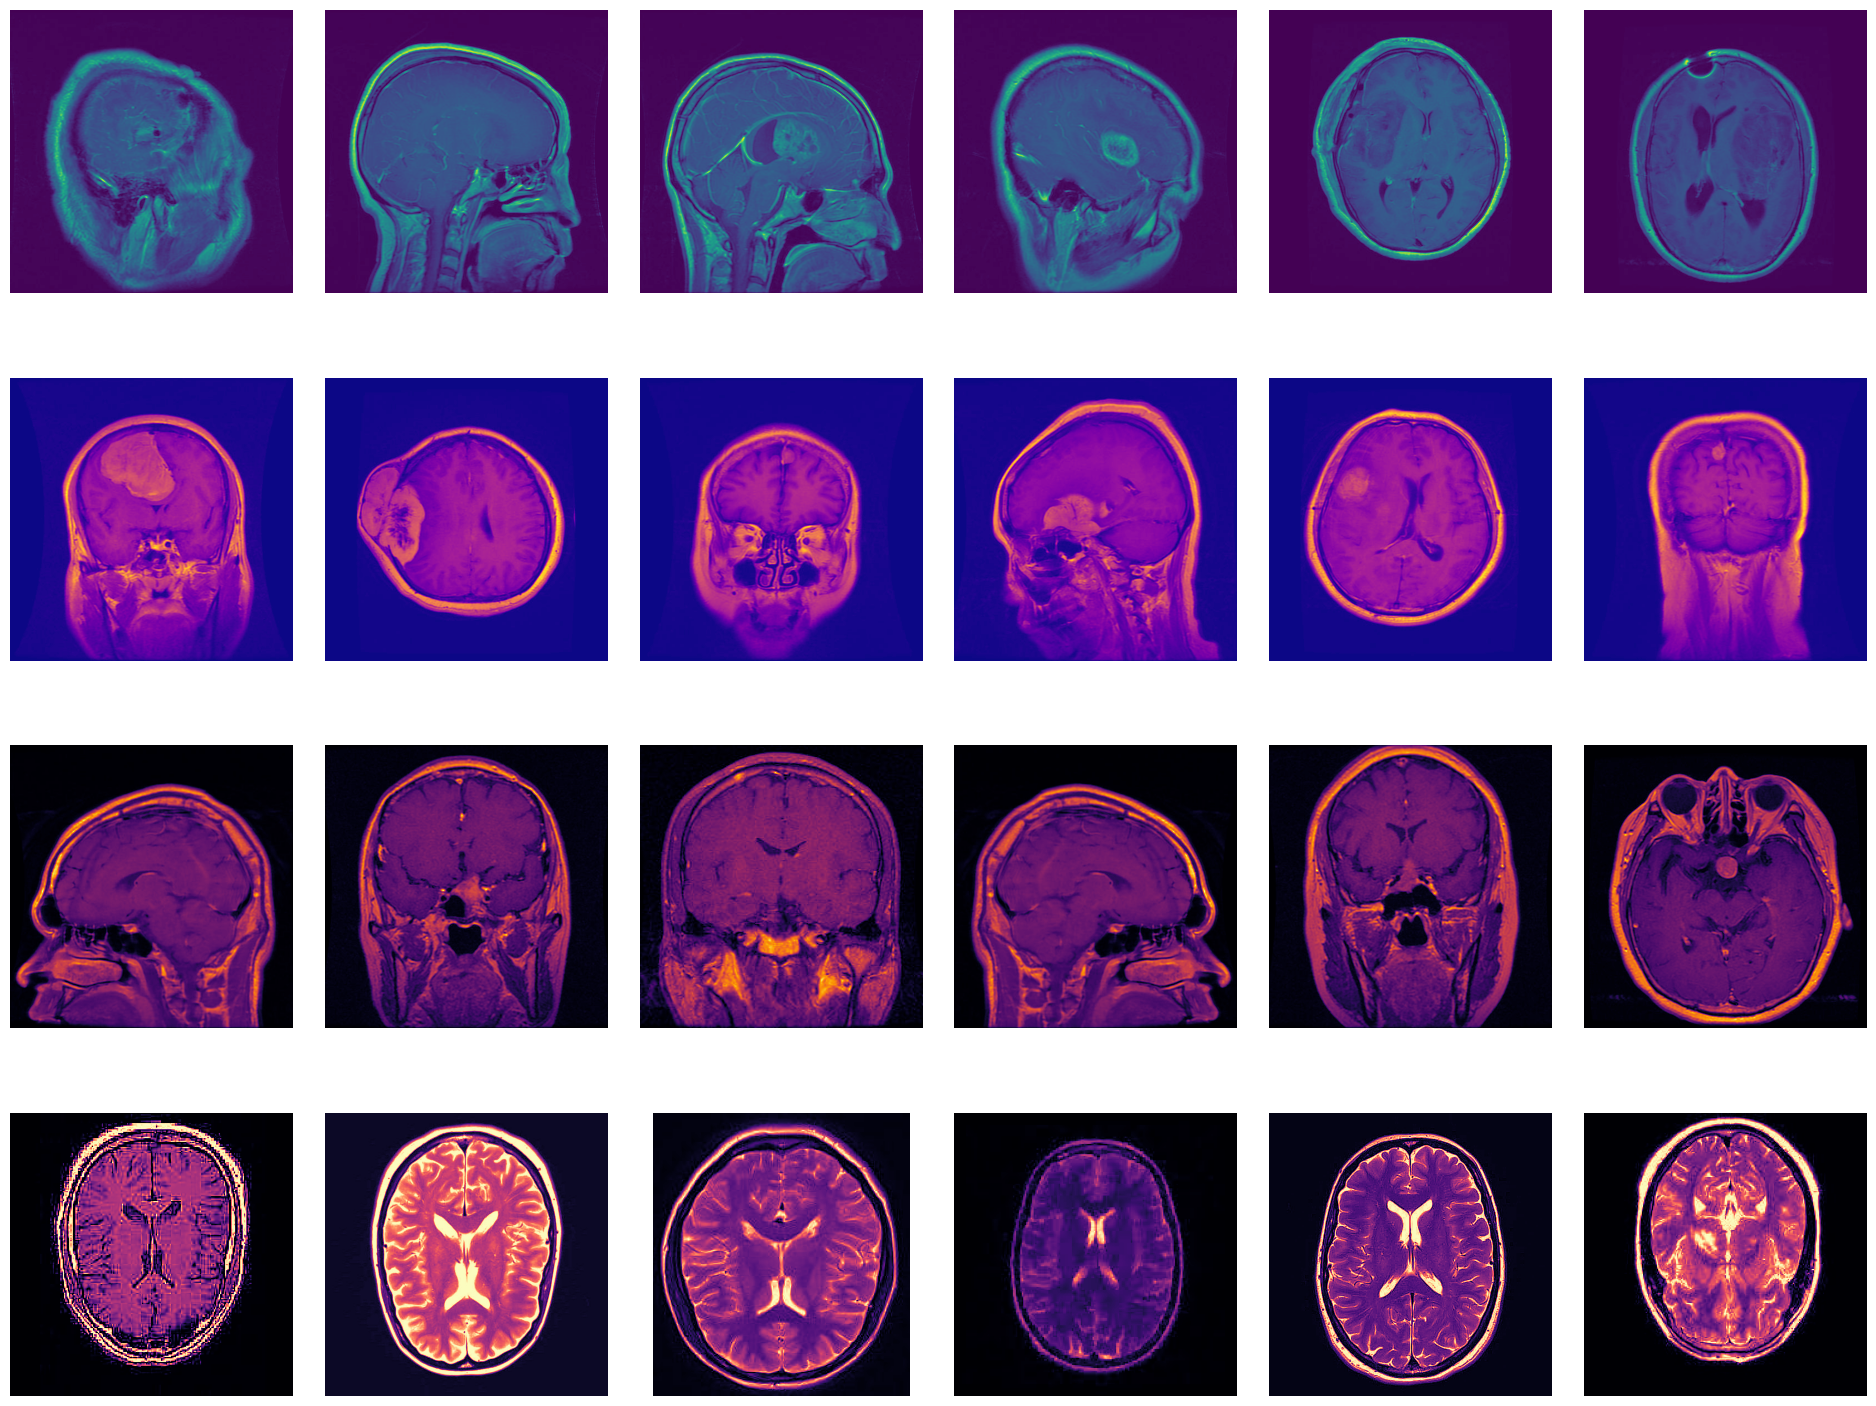

In [33]:
import os
import matplotlib.pyplot as plt
import cv2

# Define the dataset path (update this with your actual path)
dataset_path = "/kaggle/input/brain-tumor-mri-dataset/Training"  # Change this to your dataset location

# Define class names
classes = ["glioma", "meningioma", "pituitary", "notumor"]

# Function to get 5-6 sample images from each class
def get_sample_images():
    fig, axes = plt.subplots(len(classes), 6, figsize=(24, 18), dpi=100)  # Increase figure size and dpi for larger images
    
    colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']  # Different color maps for MRI images
    
    for i, cls in enumerate(classes):
        class_path = os.path.join(dataset_path, cls)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        
        for j in range(6):  # Display up to 6 images per class
            if j < len(image_files):
                img_path = os.path.join(class_path, image_files[j])
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                cmap_choice = colormaps[i % len(colormaps)]  # Cycle through colormaps
                axes[i, j].imshow(img, cmap=cmap_choice)
                axes[i, j].axis("off")
            else:
                axes[i, j].axis("off")
        
        axes[i, 0].set_ylabel(cls, fontsize=16, fontweight='bold')
    
    plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Increase spacing for better visualization
    plt.show()

# Call the function to display images
get_sample_images()

In [34]:
dir_path = '/kaggle/input/brain-tumor-mri-dataset/Training'

In [35]:
train_gen = ImageDataGenerator(
    rescale = 1.0/255,
    horizontal_flip = True,
    rotation_range = 20,
    zoom_range = 0.2,
    validation_split=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.3
)

In [36]:
train_generator = train_gen.flow_from_directory(
    dir_path,
    target_size=(224,224),
    subset='training',
    class_mode='categorical',
    batch_size=64    
)
val_ds = val_gen.flow_from_directory(
    dir_path,
    target_size=(224,224),
    subset='validation',
    class_mode='categorical',
    batch_size=64
)

Found 4000 images belonging to 4 classes.
Found 1712 images belonging to 4 classes.


In [37]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications import InceptionV3

In [38]:
base_model = InceptionV3(weights='imagenet',include_top = False, input_shape=(224,224,3))

In [ ]:
base_model.trainable=False

for layer in base_model.layers[-60:]:
    layer.trainable=True

In [ ]:
for layer in base_model.layers:
    print(layer,layer.trainable)

In [52]:
from tensorflow.keras.regularizers import l2


In [ ]:
import keras_tuner as kt1

In [ ]:
def built_model(hp):
    layer = hp.Choice('base_layer',values=[10,20,30,50,70,90,120])
    base_model.trainable=False

    for layer in base_model.layers[-layer:]:
        layer.trainable=True
        
    model = Sequential()
    
    model.add(base_model)
    model.add(Flatten())

    dropout1 = hp.Choice('dropout1', values=[0.3, 0.5])
    model.add(Dropout(dropout1))
    
    model.add(BatchNormalization())


    units = hp.Int('units', min_value=32, max_value=512, step=32)
    regularizer = hp.Float('regularizer', min_value=0.00001, max_value=0.01, step=0.0005)
    model.add(Dense(units=units, activation='relu', kernel_regularizer=l2(regularizer)))

    
    dropout2 = hp.Choice('dropout2', values=[0.3, 0.5])
    model.add(Dropout(dropout2))

    
    model.add(Dense(4, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
!rm -rf "/kaggle/working/untitled_project"

In [59]:
tuner1 = kt1.RandomSearch(
    built_model,
    objective='val_accuracy',
    max_trials=10
    )

In [60]:
tuner1.search(train_generator,validation_data = val_ds,epochs=5)

Trial 10 Complete [00h 04m 36s]
val_accuracy: 0.7733644843101501

Best val_accuracy So Far: 0.7943925261497498
Total elapsed time: 00h 45m 53s


In [62]:
tuner1.get_best_hyperparameters()[0].values

{'base_layer': 30,
 'dropout1': 0.5,
 'units': 384,
 'regularizer': 0.00151,
 'dropout2': 0.5}

In [71]:
model = tuner1.get_best_models(num_models=1)[0]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
path = "/kaggle/working/Brain_tumer_inception_model.h5"
callbacks = [
    ModelCheckpoint(filepath=path, save_best_only = True, verbose = 1, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=5,verbose = 1,  mode='min', restore_best_weights=True),
]

In [73]:
history = model.fit(train_generator,validation_data = val_ds,epochs=20,initial_epoch=5,callbacks=callbacks)

Epoch 6/20
63/63 [==============================] - ETA: 0s - loss: 4.3835 - accuracy: 0.8903
Epoch 6: val_loss improved from inf to 5.98910, saving model to /kaggle/working/ResNet_Brain_tumor_model.h5
63/63 [==============================] - 60s 885ms/step - loss: 4.3835 - accuracy: 0.8903 - val_loss: 5.9891 - val_accuracy: 0.7921
Epoch 7/20
63/63 [==============================] - ETA: 0s - loss: 4.1897 - accuracy: 0.8895
Epoch 7: val_loss improved from 5.98910 to 5.84034, saving model to /kaggle/working/ResNet_Brain_tumor_model.h5
63/63 [==============================] - 54s 858ms/step - loss: 4.1897 - accuracy: 0.8895 - val_loss: 5.8403 - val_accuracy: 0.7716
Epoch 8/20
63/63 [==============================] - ETA: 0s - loss: 3.9261 - accuracy: 0.8947
Epoch 8: val_loss improved from 5.84034 to 5.53939, saving model to /kaggle/working/ResNet_Brain_tumor_model.h5
63/63 [==============================] - 54s 864ms/step - loss: 3.9261 - accuracy: 0.8947 - val_loss: 5.5394 - val_accurac

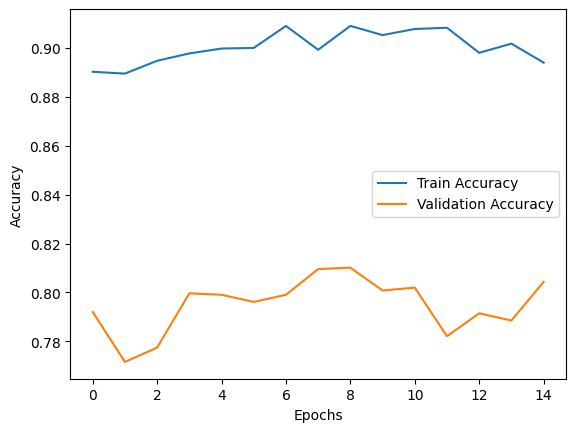

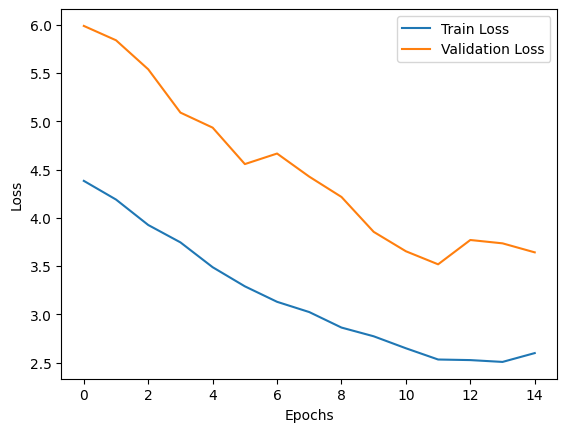

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [75]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMG_SIZE = (224, 224)
test_datagen = ImageDataGenerator(rescale=1./255)  


test_generator = test_datagen.flow_from_directory(
    test_path,    
    target_size=IMG_SIZE, 
    batch_size=32,
    class_mode='categorical',
    shuffle=False      
)

Found 5712 images belonging to 4 classes.


In [ ]:

loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

179/179 [==============================] - 15s 84ms/step - loss: 2.8152 - accuracy: 0.9058
Test Accuracy: 90.58%
Test Loss: 2.8152


In [77]:
model.save('/kaggle/working/Brain_tumer_inception_model.h5')